# Introduction

/to be filled and formatted later

# 1. Import libraries

In [2]:
import kagglehub

In [35]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.reset_option("display.max_rows")
pd.set_option("display.float_format", "{:,.0f}".format)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [5]:
import os

# 2. Data import

The following code cell is used to download the dataset files from the Kaggle website. It only needs to be executed once. \
We use library kagglehub, which provides an auth method for logging in through a web page and getting access to Kaggle datasets.

In [3]:
path = kagglehub.dataset_download("threnjen/2019-airline-delays-and-cancellations")

print("Path to dataset files:", path)

100%|██████████| 754M/754M [00:35<00:00, 22.5MB/s] 

Extracting files...


Path to dataset files: /Users/alina_yakubova/.cache/kagglehub/datasets/threnjen/2019-airline-delays-and-cancellations/versions/9


In [ ]:
df = pd.read_csv(os.path.join(path, "full_data_flightdelay.csv"))

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


1) General info

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6489062 entries, 0 to 6489061
Data columns (total 26 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   MONTH                          int64  
 1   DAY_OF_WEEK                    int64  
 2   DEP_DEL15                      int64  
 3   DEP_TIME_BLK                   str    
 4   DISTANCE_GROUP                 int64  
 5   SEGMENT_NUMBER                 int64  
 6   CONCURRENT_FLIGHTS             int64  
 7   NUMBER_OF_SEATS                int64  
 8   CARRIER_NAME                   str    
 9   AIRPORT_FLIGHTS_MONTH          int64  
 10  AIRLINE_FLIGHTS_MONTH          int64  
 11  AIRLINE_AIRPORT_FLIGHTS_MONTH  int64  
 12  AVG_MONTHLY_PASS_AIRPORT       int64  
 13  AVG_MONTHLY_PASS_AIRLINE       int64  
 14  FLT_ATTENDANTS_PER_PASS        float64
 15  GROUND_SERV_PER_PASS           float64
 16  PLANE_AGE                      int64  
 17  DEPARTING_AIRPORT              str    
 18  LATITUDE     

1.2 Descriptive statistics for numerical data

In [21]:
df.describe()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,AIRPORT_FLIGHTS_MONTH,AIRLINE_FLIGHTS_MONTH,AIRLINE_AIRPORT_FLIGHTS_MONTH,AVG_MONTHLY_PASS_AIRPORT,AVG_MONTHLY_PASS_AIRLINE,FLT_ATTENDANTS_PER_PASS,GROUND_SERV_PER_PASS,PLANE_AGE,LATITUDE,LONGITUDE,PRCP,SNOW,SNWD,TMAX,AWND
count,"6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062","6,489,062"
mean,7,4,0,4,3,28,134,"12,685","62,961","3,459","1,588,639","7,814,970",0,0,12,37,-94,0,0,0,71,8
std,3,2,0,2,2,22,46,"8,840","34,382","4,251","1,123,847","5,046,882",0,0,7,6,18,0,0,1,18,4
min,1,1,0,1,1,1,44,"1,100","5,582",1,"70,476","473,794",0,0,0,18,-159,0,0,0,-10,0
25%,4,2,0,2,2,11,90,"5,345","25,034",654,"673,221","2,688,839",0,0,5,33,-106,0,0,0,59,6
50%,7,4,0,3,3,23,143,"11,562","70,878","2,251","1,486,066","8,501,631",0,0,12,38,-88,0,0,0,74,8
75%,10,6,0,5,4,39,172,"17,615","86,312","4,806","2,006,675","12,460,183",0,0,17,41,-81,0,0,0,86,10
max,12,7,1,11,15,109,337,"35,256","117,728","21,837","4,365,661","13,382,999",0,0,32,61,-66,12,17,25,115,34


1.3 Descriptive statistics for categorical data

In [22]:
df.describe(include="object")

/var/folders/78/8b3g8thx1b99pgrq0245szkr0000gn/T/ipykernel_26308/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,DEP_TIME_BLK,CARRIER_NAME,DEPARTING_AIRPORT,PREVIOUS_AIRPORT
count,6489062,6489062,6489062,6489062
unique,19,17,96,356
top,0800-0859,Southwest Airlines Co.,Atlanta Municipal,NONE
freq,452391,1296329,392603,1449009


# 3. Data Understanding and Preparation

3.1 Duplicates

In [23]:
n_dup = df.duplicated().sum()
print(f"Duplicate rows: {n_dup:,}  ({n_dup / len(df):.2%})")

Duplicate rows: 28,473  (0.44%)


Drop duplicates

In [24]:
df = df.drop_duplicates().reset_index(drop=True)

3.2 Type conversions

- Convert monthes and days of week into strings
- Extract hour from departure time

In [28]:
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_ORDER   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

In [29]:
MONTH_MAP = dict(zip(range(1, 13), MONTH_ORDER))
DOW_MAP   = dict(zip(range(1, 8),  DOW_ORDER))

df["MONTH_NAME"] = pd.Categorical(
    df["MONTH"].map(MONTH_MAP), categories=MONTH_ORDER, ordered=True
)
df["DAY_NAME"] = pd.Categorical(
    df["DAY_OF_WEEK"].map(DOW_MAP), categories=DOW_ORDER, ordered=True
)

In [30]:
df["DEP_HOUR"] = df["DEP_TIME_BLK"].str[:2].astype(int)

df[["MONTH","MONTH_NAME","DAY_OF_WEEK","DAY_NAME",
    "DEP_TIME_BLK","DEP_HOUR"]].head(3)

,MONTH,MONTH_NAME,DAY_OF_WEEK,DAY_NAME,DEP_TIME_BLK,DEP_HOUR
0,1,Jan,7,Sun,0800-0859,8
1,1,Jan,7,Sun,0700-0759,7
2,1,Jan,7,Sun,0600-0659,6


3.3 Target distribution (total on-time vs delayed)

In [ ]:
def plot_target_distribution(df, target="DEP_DEL15"):
    """
    Bar chart showing class balance for a binary target column.
    """
    counts = df[target].value_counts().sort_index()
    labels = ["On Time", "Delayed (>15 min)"]
    colors = ["steelblue", "tomato"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)

    ax.set_ylim(0, max(counts.values) * 1.2)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f"{val:,}\n({val / len(df):.1%})",
            ha="center", va="bottom", fontsize=11,
        )
    ax.set_title("Flight Delay Distribution (DEP_DEL15)", fontsize=13)
    ax.set_ylabel("Number of Flights")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    plt.tight_layout()
    plt.show()

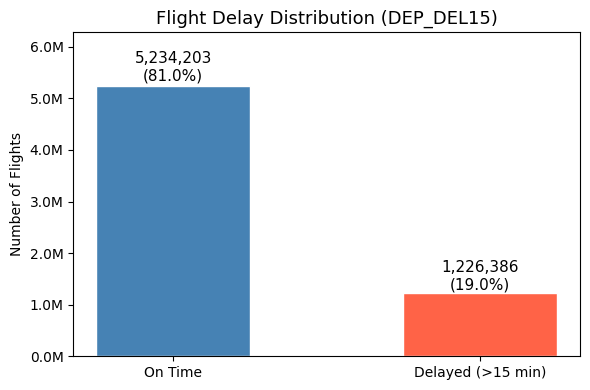

In [41]:
plot_target_distribution(df)

3.4 Categorical feature histograms

In [46]:
def plot_categorical_histogram(df, col, top_n=20, figsize=(12, 4),
                               category_order=None):
    """
    Bar chart for a categorical column with delay rate overlay.
    
    col            : column name
    top_n          : keep top N categories by count (ignored if category_order given)
    category_order : explicit list to fix x-axis order (e.g. month names)
    """
    if category_order:
        counts = df[col].value_counts().reindex(category_order).dropna()
    else:
        counts = df[col].value_counts().head(top_n)

    delay_rate = df.groupby(col)["DEP_DEL15"].mean().reindex(counts.index)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(counts.index.astype(str), counts.values,
            color="steelblue", alpha=0.85, label="Flight Count")
    ax1.set_ylabel("Flight Count", color="steelblue")
    ax1.tick_params(axis="x", rotation=45)
    plt.setp(ax1.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x < 1e6 else f"{x/1e6:.1f}M")
    )

    ax2 = ax1.twinx()
    ax2.plot(counts.index.astype(str), delay_rate.values,
             "o-", color="tomato", linewidth=2, label="Delay Rate")
    ax2.set_ylabel("Delay Rate", color="tomato")
    ax2.set_ylim(0, 0.5)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

    lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax1.legend(lines, labels, loc="upper right", fontsize=8)
    ax1.set_title(f"{col} — Flight Count & Delay Rate", fontsize=11)

    plt.tight_layout()
    plt.show()

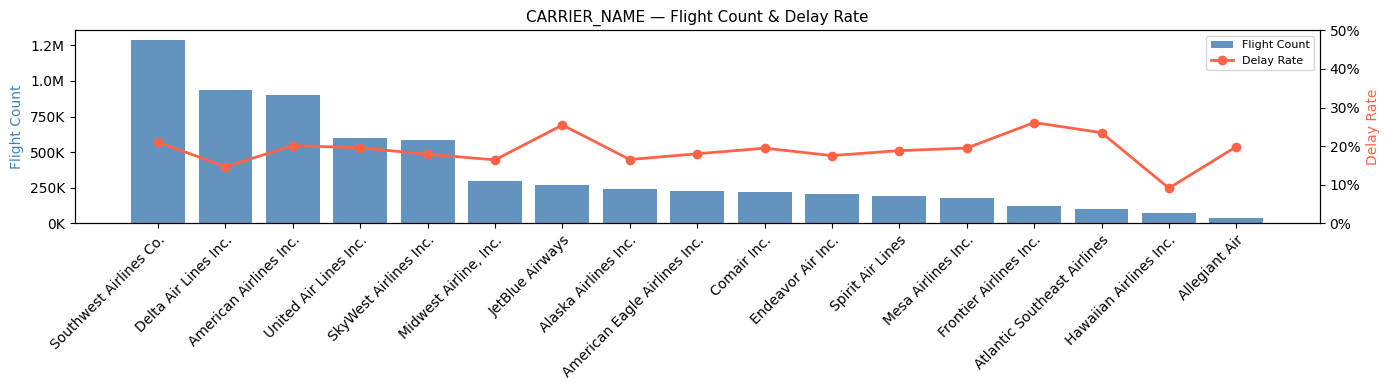

In [47]:
plot_categorical_histogram(df, "CARRIER_NAME", figsize=(14, 4))

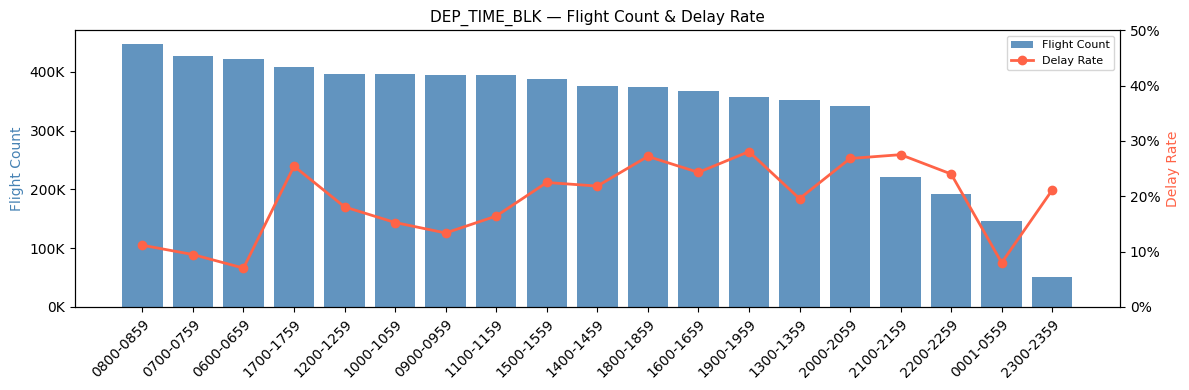

In [48]:
plot_categorical_histogram(df, "DEP_TIME_BLK")

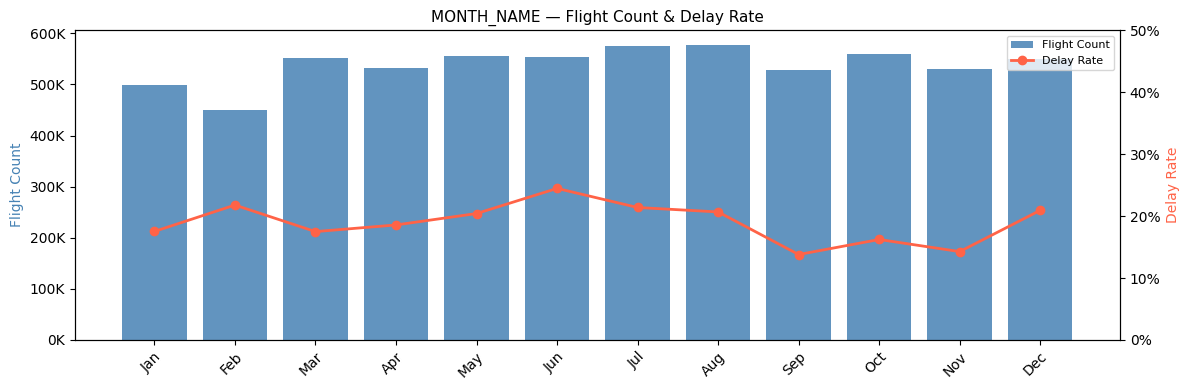

In [49]:
plot_categorical_histogram(df, "MONTH_NAME",  category_order=MONTH_ORDER)

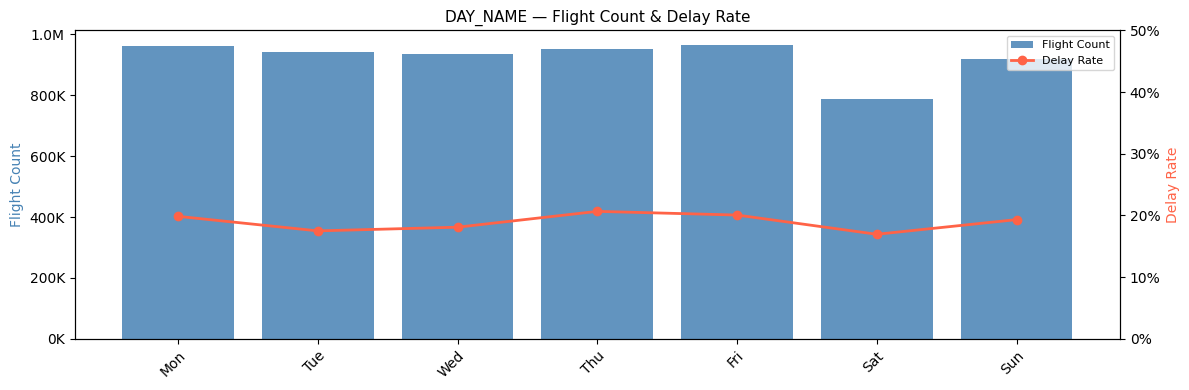

In [50]:
plot_categorical_histogram(df, "DAY_NAME",    category_order=DOW_ORDER)

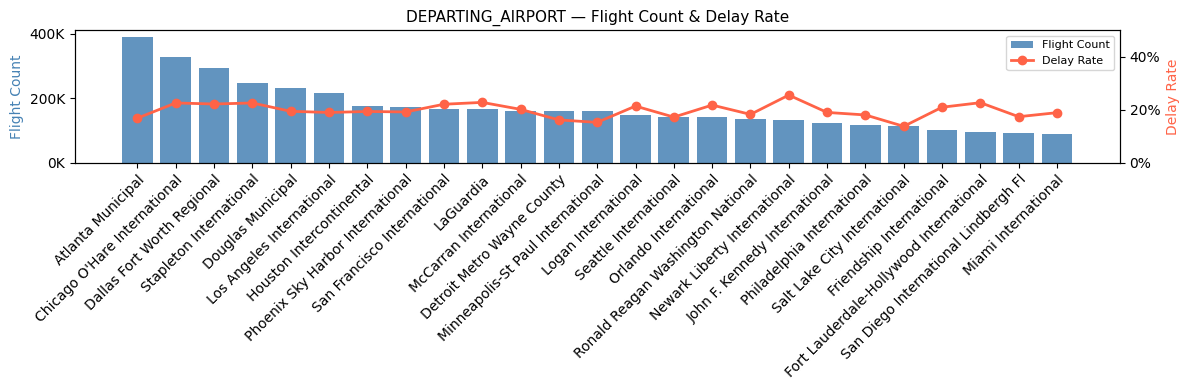

In [51]:
plot_categorical_histogram(df, "DEPARTING_AIRPORT", top_n=25)